In [6]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pickle
import os 
import sys

from scipy.special import lambertw
from scipy.stats import poisson 

import scipy.sparse
from matplotlib.lines import Line2D 

from multiprocessing import Pool

from tqdm import tqdm


dir_path = os.path.dirname(os.getcwd())
sys.path.append(dir_path)

In [66]:
with open("/mnt/hdd_bob/syy/adipose/atac/defnd_seq/samplesheet.csv") as f:
    next(f)
    samples = {line.split(',')[1]: 'dna10x_output' for line in f}
    

directory = '/mnt/hdd_bob/syy/adipose/atac/defnd_seq'
for sample in samples:
    project = samples[sample]
    fastqpath = directory+'/outs/fastq_path/'+project+'/'+sample+'/*'
    print(fastqpath)



/mnt/hdd_bob/syy/adipose/atac/defnd_seq/outs/fastq_path/dna10x_output/BJ_Cell_ATAC
/*
/mnt/hdd_bob/syy/adipose/atac/defnd_seq/outs/fastq_path/dna10x_output/BJ_Cell_LAND
/*
/mnt/hdd_bob/syy/adipose/atac/defnd_seq/outs/fastq_path/dna10x_output/BJ_CELL_xSDS
/*


# Plot

In [6]:
land='/home/syyang/adipose_ln/atac/res/BJ_Cell_LAND'
atac='/home/syyang/adipose_ln/atac/res/BJ_Cell_ATAC'
xSDS='/home/syyang/adipose_ln/atac/res/BJ_CELL_xSDS'


# for path in [land, atac, xSDS]:
land_frag = pd.read_csv(os.path.join(land, 'total_fragments_counts.txt'), index_col=1, header=None, sep=' ')
atac_frag = pd.read_csv(os.path.join(atac, 'total_fragments_counts.txt'), index_col=1, header=None, sep=' ')
xSDS_frag = pd.read_csv(os.path.join(xSDS, 'total_fragments_counts.txt'), index_col=1, header=None, sep=' ')

In [8]:
land_frag.describe(), xSDS_frag.describe(), atac_frag.describe()

(                  0
 count  9.557502e+06
 mean   7.390752e+01
 std    3.228435e+03
 min    1.000000e+00
 25%    1.000000e+00
 50%    1.000000e+00
 75%    1.000000e+00
 max    7.102081e+06,
                   0
 count  2.107755e+06
 mean   4.124429e+01
 std    3.090342e+03
 min    1.000000e+00
 25%    1.000000e+00
 50%    1.000000e+00
 75%    1.000000e+00
 max    1.247843e+06,
                   0
 count  4.779891e+06
 mean   3.673482e+01
 std    2.203025e+03
 min    1.000000e+00
 25%    1.000000e+00
 50%    1.000000e+00
 75%    1.000000e+00
 max    2.091546e+06)

In [1]:
32338 - 31116, 38001 - 36729

(1222, 1272)

In [92]:
precision=1e-7

fig_res_dir = '/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_RES'

In [93]:
# ws = 2000000
# ws = 1000000
# ws = 100000
# ws = 50000  # Might be too big
# ws = 30000  # might be too big
# ws = 10000
# ws=5000
ws = 3000
# ws=500
# ws=300

output_dir = f'/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS{ws}N'
chromosome = 'chr1'

crbarcode_file = os.path.join(output_dir, '/outs/filtered_peak_bc_matrix/barcodes.tsv')

frag_overlap_subdir = os.path.join(output_dir, 'fragments_overlap_peaks')

entropy_cutoff_file = os.path.join(output_dir, 'entropy_cutoff.csv')


In [94]:
from utils import return_none

tn5_inser_freq_file = os.path.join(output_dir, f'{chromosome}_insert_frequency.pickle')

with open(tn5_inser_freq_file, 'rb') as f:
    tn5_insert_freq = pickle.load(f)

In [129]:
entropy_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy.pickle')

with open(entropy_file, 'rb') as f:
    entropy_dict = pickle.load(f)
    
    
entropy = np.array(list(entropy_dict.values()))
entropy.sort() # sort the entropy values


bc_entropy = pd.DataFrame.from_dict(entropy_dict, orient='index', columns=['entropy'])


with open(entropy_cutoff_file, 'r') as f:
    entropy_cutoff = float(f.readline().strip().split(',')[1])

In [96]:
summary_statistics_frag_overlap_entropypeaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                          'summary_statistics_frag_overlap_entropypeaks.csv'), sep='\t', 
                                                              index_col=0)
summary_statistics_frag_overlap_entropypeaks_df.index.name = None

summary_statistics_frag_overlap_peaks_df = pd.read_csv(os.path.join(frag_overlap_subdir,
                                                                 'summary_statistics_frag_overlap_peaks.csv'), sep='\t', 
                                                     index_col=0)
summary_statistics_frag_overlap_peaks_df.index.name = None

In [99]:

def mixdist_mle_entropy(tn5_insert_array:scipy.sparse):
    
    Mtotal = tn5_insert_array.shape[1] # total number of windows
    
    row_indices, col_indices, non0_insert =scipy.sparse.find(tn5_insert_array)
    Mnon0 = non0_insert.shape[0]
    
    
    non0_insert_adjusted = (non0_insert + 1) // 2 # adjust for paired-end sequencing
    cur_adjusted, freq_adjusted = np.unique(non0_insert_adjusted, return_counts=True)
    
    ZTP_prob = freq_adjusted / Mnon0
    mean_adjusted = np.matmul(cur_adjusted, ZTP_prob) 

    if mean_adjusted <= 1:
        return None, None, Mnon0, None, None, None
    # mean_adjusted += precision  # to avoid numerical issues 
    
    # Lambert W function requires (-M1 * exp(-M1)) > -1/e --> mean_adjusted > 1 
    mle_lambda = lambertw( -mean_adjusted * np.exp(-mean_adjusted) , k=0).real + mean_adjusted
    P0 = np.exp(-mle_lambda)
    

    N0_openregion = Mnon0 / ( 1- P0) * P0
    p_closestate = 1 -  (N0_openregion + Mnon0) / Mtotal
    
    if p_closestate < 0:
        return None, None, Mnon0, None, None, None

    # Entropy of mix states
    Entropy_states = -np.log2( p_closestate ) * p_closestate - np.log2(1 - p_closestate) * (1 - p_closestate)
    
    # Entropy only for open regions under Poisson model
    Poisson_prob = ZTP_prob * (1 - P0) # Only for non-zero windows in open region
    Entropy_openregion = -np.matmul(Poisson_prob, np.log2(Poisson_prob)) - P0 * np.log2(P0) 
    
    # Entropy_mixturedist = Entropy_states + (1 - p_closestate) * Entropy_openregion 
    #Entropy_mixturedist = Entropy_states + (1 - p_closestate) * Entropy_openregion  / mean_adjusted / Mnon0 # adjust by read depth
    Entropy_mixturedist = Entropy_states + (1 - p_closestate) * Entropy_openregion  / Mnon0 * (1 - P0) # adjust by Poisson sample size


    return Entropy_mixturedist, Entropy_openregion, Mnon0, mle_lambda, P0, p_closestate


def kl_divergence(mle_lambda, cur, freq):
    """ Compute KL divergence D_KL(P||Q) for discrete distributions
        p and q are arrays of the same length representing probability distributions
    """
    # q is from Poisson distribution with parameter mle_lambda
    
    p = freq / np.sum(freq)
    log_q = np.array([poisson.logpmf(k, mle_lambda) for k in cur]) 
    
    divergence = np.sum( p * (np.log(p) - log_q) )
    
    return divergence

In [100]:
barcode_entropy_df_file = os.path.join(output_dir, f'{chromosome}_barcode_entropy_dynamic.csv')

with open(barcode_entropy_df_file, 'w') as f:
            f.write(",Entropy_mixturedist,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state\n")
            for bc, v in tqdm(tn5_insert_freq.items(), desc="Calculating entropy for each cell barcode"):
                Entropy_mixturedist, Entropy_open_region, Mp, mle_lambda, p0, p_closed_state = mixdist_mle_entropy(v)
                if Entropy_mixturedist is None:
                    continue
                f.write(f"{bc},{Entropy_mixturedist},{Entropy_open_region},{Mp},{mle_lambda},{p0},{p_closed_state}\n")


Calculating entropy for each cell barcode: 100%|██████████| 87945/87945 [00:13<00:00, 6714.02it/s]


In [101]:
entropy_df = summary_statistics_frag_overlap_entropypeaks_df.join(summary_statistics_frag_overlap_peaks_df,
                                                                  lsuffix='_entropypeaks', rsuffix='_peaks')

entropy_df = entropy_df.join(bc_entropy, how='outer')


entropy_dyn_df = pd.read_csv(barcode_entropy_df_file, index_col=0 )

entropy_df = entropy_df.join(entropy_dyn_df, how='inner')

entropy_df.shape

(33287, 15)

In [102]:
entropy_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,entropy_entropypeaks,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy_peaks,entropy,Entropy_mixturedist,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state
AAACAAGCAAACCTAG-1,207,18.0,8.695652,0.011025,207,16.0,7.729469,0.011025,0.011025,0.011025,1.123864,25,0.376438,0.686302,0.999040
AAACAAGCAAAGAAGC-1,987,47.0,4.761905,0.011332,987,43.0,4.356636,0.011332,0.011332,0.011332,2.467013,72,2.094841,0.123090,0.999011
AAACAAGCAAATCCCT-1,242,23.0,9.504132,0.010227,242,21.0,8.677686,0.010227,0.010227,0.010227,0.903598,19,0.300738,0.740272,0.999118
AAACAAGCAACAGGGA-1,107,16.0,14.953271,0.005639,107,16.0,14.953271,0.005639,0.005639,0.005639,1.070946,13,0.430714,0.650044,0.999552
AAACAAGCAAGGGCTT-1,66,7.0,10.606061,0.003780,66,7.0,10.606061,0.003780,0.003780,0.003780,1.181182,10,0.549861,0.577030,0.999715


## Load CR's barcodes info 

In [103]:
cr_clustering_file = '/mnt/hdd_bob/syy/adipose/atac/protocol_benchmark/cr_results/atac/VIB_10xmultiome_2/outs/analysis/clustering/graphclust/clusters.csv'

cr_clustering_df = pd.read_csv(cr_clustering_file, sep=',', index_col=0)

In [104]:
all_df = entropy_df.join(cr_clustering_df, how='outer')
all_df['log(total_fragments)'] = np.log10(all_df['total_fragments_entropypeaks'] + precision)
all_df['log(entropy)'] = np.log10(all_df['entropy'] + precision)
# Create a binary column indicating whether a barcode is a cell by CR's cell calling
all_df['cr_bc'] = ~all_df['Cluster'].isna()

In [105]:
all_df.head()

,total_fragments_entropypeaks,frag_overlap_entropy_peaks,frag_overlap_entropy_peaks%,entropy_entropypeaks,total_fragments_peaks,frag_overlap_peaks,frag_overlap_peaks%,entropy_peaks,entropy,Entropy_mixturedist,Entropy_open_region,Mp,mle_lambda,P0_open_region,P_closed_state,Cluster,log(total_fragments),log(entropy),cr_bc
AAACAAGCAAACCTAG-1,207.0,18.0,8.695652,0.011025,207.0,16.0,7.729469,0.011025,0.011025,0.011025,1.123864,25.0,0.376438,0.686302,0.999040,NaN,2.315970,-1.957621,False
AAACAAGCAAAGAAGC-1,987.0,47.0,4.761905,0.011332,987.0,43.0,4.356636,0.011332,0.011332,0.011332,2.467013,72.0,2.094841,0.123090,0.999011,NaN,2.994317,-1.945697,False
AAACAAGCAAATCCCT-1,242.0,23.0,9.504132,0.010227,242.0,21.0,8.677686,0.010227,0.010227,0.010227,0.903598,19.0,0.300738,0.740272,0.999118,NaN,2.383815,-1.990228,False
AAACAAGCAACAGGGA-1,107.0,16.0,14.953271,0.005639,107.0,16.0,14.953271,0.005639,0.005639,0.005639,1.070946,13.0,0.430714,0.650044,0.999552,NaN,2.029384,-2.248814,False
AAACAAGCAAGGGCTT-1,66.0,7.0,10.606061,0.003780,66.0,7.0,10.606061,0.003780,0.003780,0.003780,1.181182,10.0,0.549861,0.577030,0.999715,NaN,1.819544,-2.422441,False


# Open region Entropy adjusted by sample-size (indirectly read-depth)

Text(0, 0.5, 'log(Entropy)')

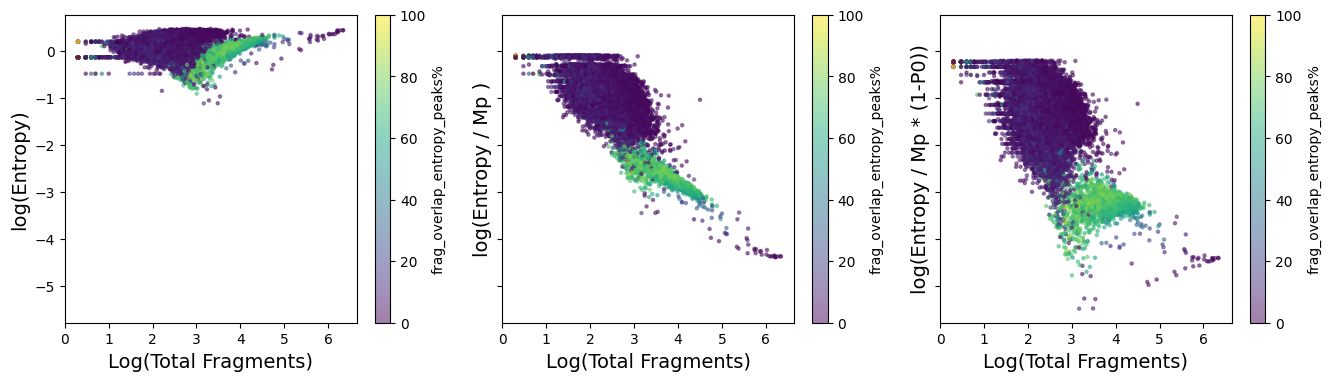

In [115]:

fig, ax = plt.subplots(1, 3, figsize=(16,4), sharey=True)
ax[2].scatter( all_df['log(total_fragments)'], 
              np.log10(all_df['Entropy_open_region'] / all_df['Mp'] *  (1- all_df['P0_open_region'])), c= all_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
ax[2].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[2].set_ylabel('log(Entropy / Mp * (1-P0))', fontsize=14)
fig.colorbar(ax[2].collections[0], ax=ax[2], label='frag_overlap_entropy_peaks%')


ax[1].scatter( all_df['log(total_fragments)'], 
              np.log10(all_df['Entropy_open_region'] / all_df['Mp'] ), c= all_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
ax[1].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[1].set_ylabel('log(Entropy / Mp )', fontsize=14)
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[0].scatter( all_df['log(total_fragments)'],
                np.log10(all_df['Entropy_open_region']) , c= all_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')
ax[0].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[0].set_ylabel('log(Entropy)', fontsize=14)

## Plot Mixture Entropy

In [107]:
all_df['Entropy_mixturedist'].sort_values(ascending=False).head()

CGTGTTTCAAACCTAG-1    0.998157
TCCTCCATCAGGTTCC-1    0.985064
CAAACAATCAGCCTGT-1    0.977556
AGCTTCCAGCTTACTG-1    0.970420
CAACATAAGCAAGGAA-1    0.970204
Name: Entropy_mixturedist, dtype: float64

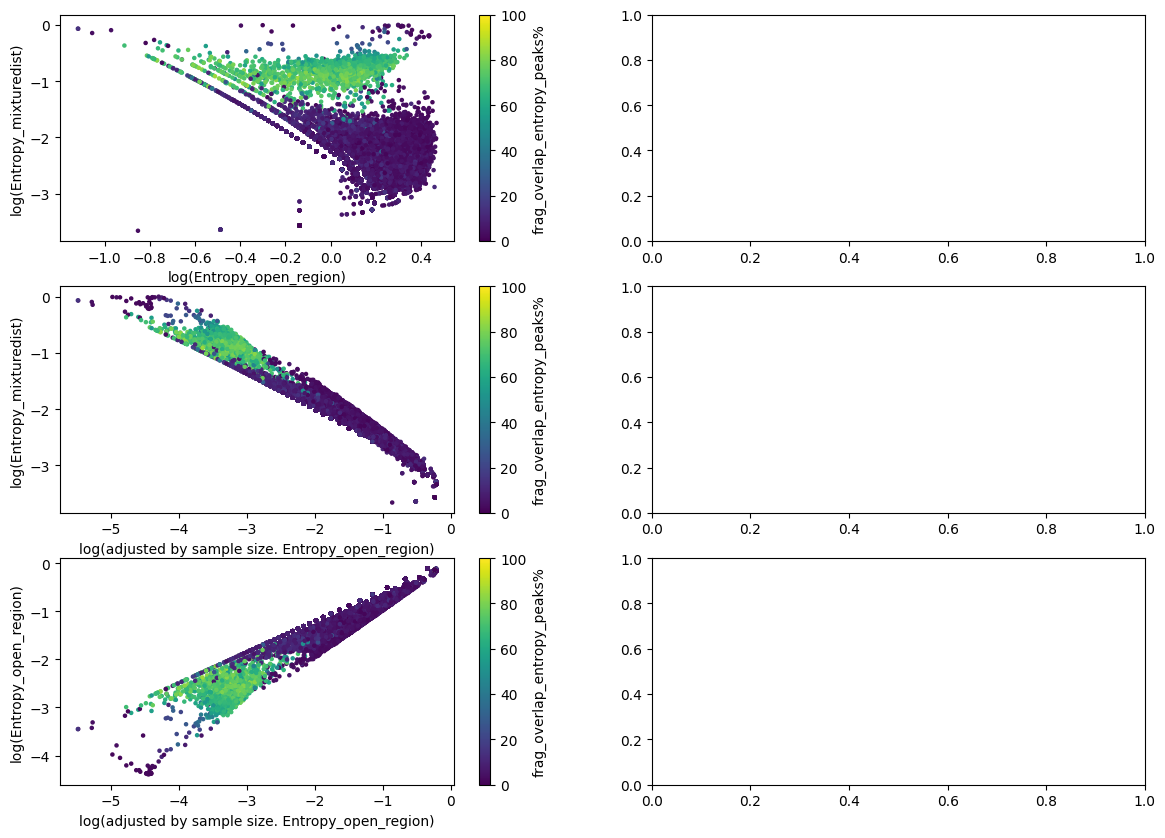

In [108]:
fig, ax = plt.subplots(3, 2, figsize=(14,10))
ax[0,0].scatter( np.log10(all_df['Entropy_open_region']), np.log10(all_df['Entropy_mixturedist']+ precision), c=all_df['frag_overlap_entropy_peaks%'], s = 5, )
ax[0,0].set_xlabel('log(Entropy_open_region)')
ax[0,0].set_ylabel('log(Entropy_mixturedist)')
fig.colorbar(ax[0,0].collections[0], ax=ax[0,0], label='frag_overlap_entropy_peaks%')


ax[1,0].scatter( np.log10(all_df['Entropy_open_region']/  all_df['Mp'] * (1- all_df['P0_open_region'])), np.log10(all_df['Entropy_mixturedist'] ), c=all_df['frag_overlap_entropy_peaks%'], s = 5, )
ax[1,0].set_xlabel('log(adjusted by sample size. Entropy_open_region)')
ax[1,0].set_ylabel('log(Entropy_mixturedist)')
fig.colorbar(ax[1,0].collections[0], ax=ax[1,0], label='frag_overlap_entropy_peaks%')


ax[2,0].scatter(  np.log10(all_df['Entropy_open_region']/  all_df['Mp'] * (1- all_df['P0_open_region'])), np.log10(all_df['Entropy_open_region']/  all_df['Mp']), c=all_df['frag_overlap_entropy_peaks%'], s = 5, )
ax[2,0].set_xlabel('log(adjusted by sample size. Entropy_open_region)')
ax[2,0].set_ylabel('log(Entropy_open_region)')
fig.colorbar(ax[2,0].collections[0], ax=ax[2,0], label='frag_overlap_entropy_peaks%')


# # 2nd column 
# ax[0,1].scatter(np.log10(all_df['Entropy_open_region']/  all_df['Mp']), all_df['P0_open_region'], c=all_df['frag_overlap_entropy_peaks%'], s = 5, )

/tmp/ipykernel_3645555/2413895305.py:10: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision),  c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),


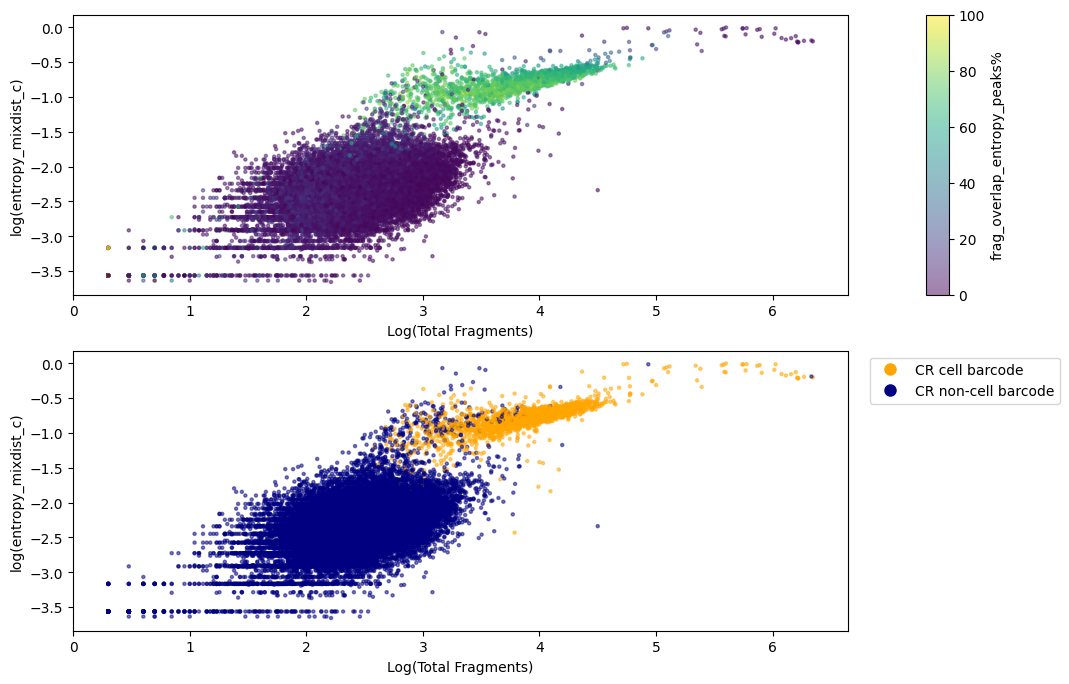

In [109]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist_c)')




ax[1].scatter(all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision),  c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),
              alpha=0.5, s=5, cmap='coolwarm')
ax[1].set_xlabel('Log(Total Fragments)')
ax[1].set_ylabel('log(entropy_mixdist_c)')
ax[1].legend( handles=[Line2D([0], [0], marker='o', color='w', label='CR cell barcode',
                          markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='CR non-cell barcode',
                           markerfacecolor='navy', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')

# Align colorbar and legend
cbax_0 = ax[0].inset_axes([1.1, 0, 0.03, 1], transform=ax[0].transAxes)
fig.colorbar(ax[0].collections[0], ax=ax[0], cax=cbax_0, label='frag_overlap_entropy_peaks%')



fig.subplots_adjust(wspace=0.3)

/tmp/ipykernel_3645555/1103996747.py:12: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[1].scatter(all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision),  c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),


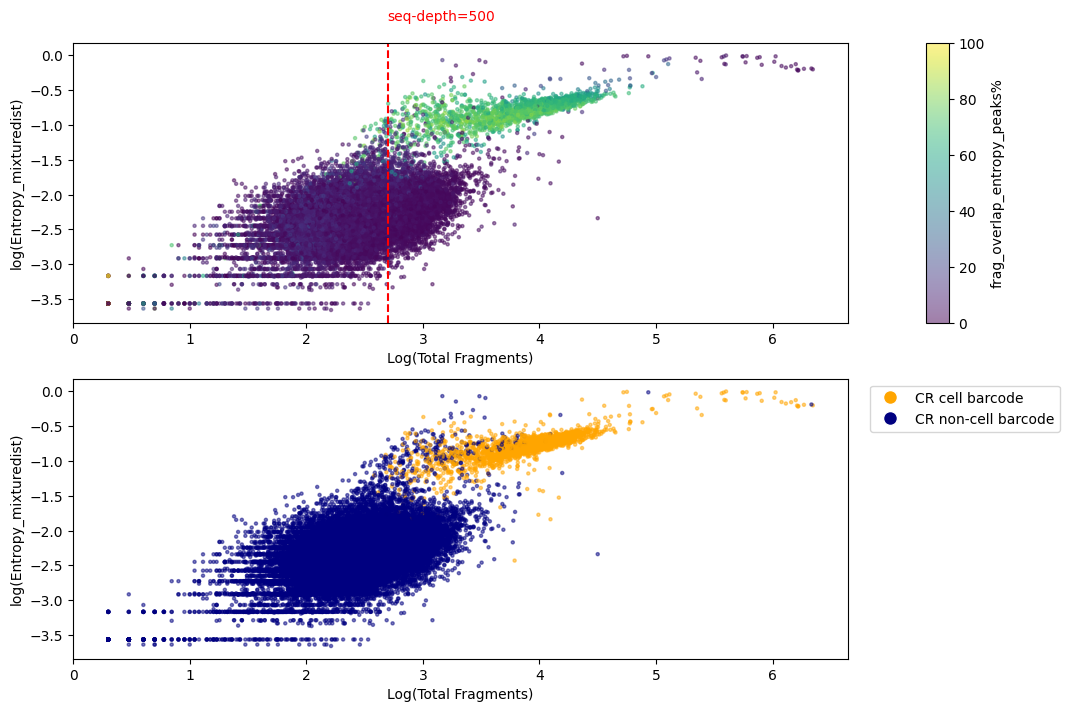

In [110]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(Entropy_mixturedist)')
ax[0].axvline(np.log10(500), color='red', linestyle='--', label='seq-depth=500')
ax[0].text(np.log10(500), .5, 'seq-depth=500', color='red')




ax[1].scatter(all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision),  c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),
              alpha=0.5, s=5, cmap='coolwarm')
ax[1].set_xlabel('Log(Total Fragments)')
ax[1].set_ylabel('log(Entropy_mixturedist)')
ax[1].legend( handles=[Line2D([0], [0], marker='o', color='w', label='CR cell barcode',
                          markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='CR non-cell barcode',
                           markerfacecolor='navy', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')

# Align colorbar and legend
cbax_0 = ax[0].inset_axes([1.1, 0, 0.03, 1], transform=ax[0].transAxes)
fig.colorbar(ax[0].collections[0], ax=ax[0], cax=cbax_0, label='frag_overlap_entropy_peaks%')


fig.subplots_adjust(wspace=0.3)

# And what

In [130]:
entropy_cutoff

0.05894226413735707

Text(0.5, 1.0, 'Entropy_mixturedist distribution on \n CR-called cells vs non-cells')

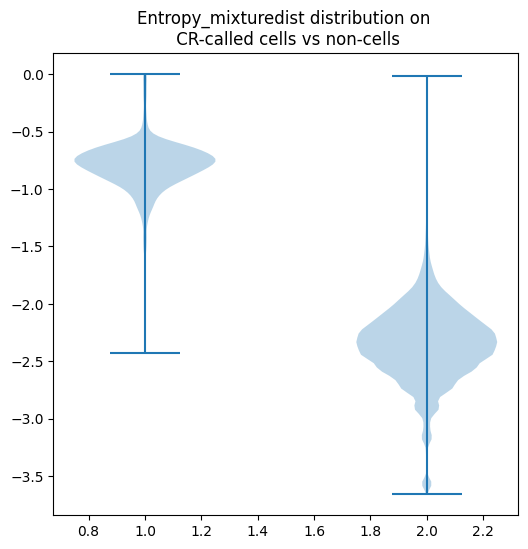

In [111]:
fig, ax = plt.subplots(1, figsize=(6 ,6))
ax.violinplot([np.log10(all_df.loc[all_df['cr_bc'], 'Entropy_mixturedist'].dropna()+ precision) ,
                          np.log10(all_df.loc[~all_df['cr_bc'], 'Entropy_mixturedist'].dropna()+ precision)],
               showmeans=False)
ax.set_title('Entropy_mixturedist distribution on \n CR-called cells vs non-cells')


In [132]:
all_df['entropy_pass'] = (all_df['Entropy_mixturedist'] > entropy_cutoff)


all_df['identified_by'] = all_df.apply(
    lambda row: 'both' if row['entropy_pass'] and row['cr_bc'] else 
                ('entropy_only' if row['entropy_pass'] and not row['cr_bc'] else 
                 ('cr_only' if not row['entropy_pass'] and row['cr_bc'] else 'none')), axis=1
)

all_df['identified_by'].value_counts() , print(f'number of cells passed entropy: {all_df["entropy_pass"].values.sum()}')

number of cells passed entropy: 2123


(identified_by
 none            31105
 both             1887
 entropy_only      236
 cr_only            72
 Name: count, dtype: int64,
 None)

/tmp/ipykernel_3645555/2480629233.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[2].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision), c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),


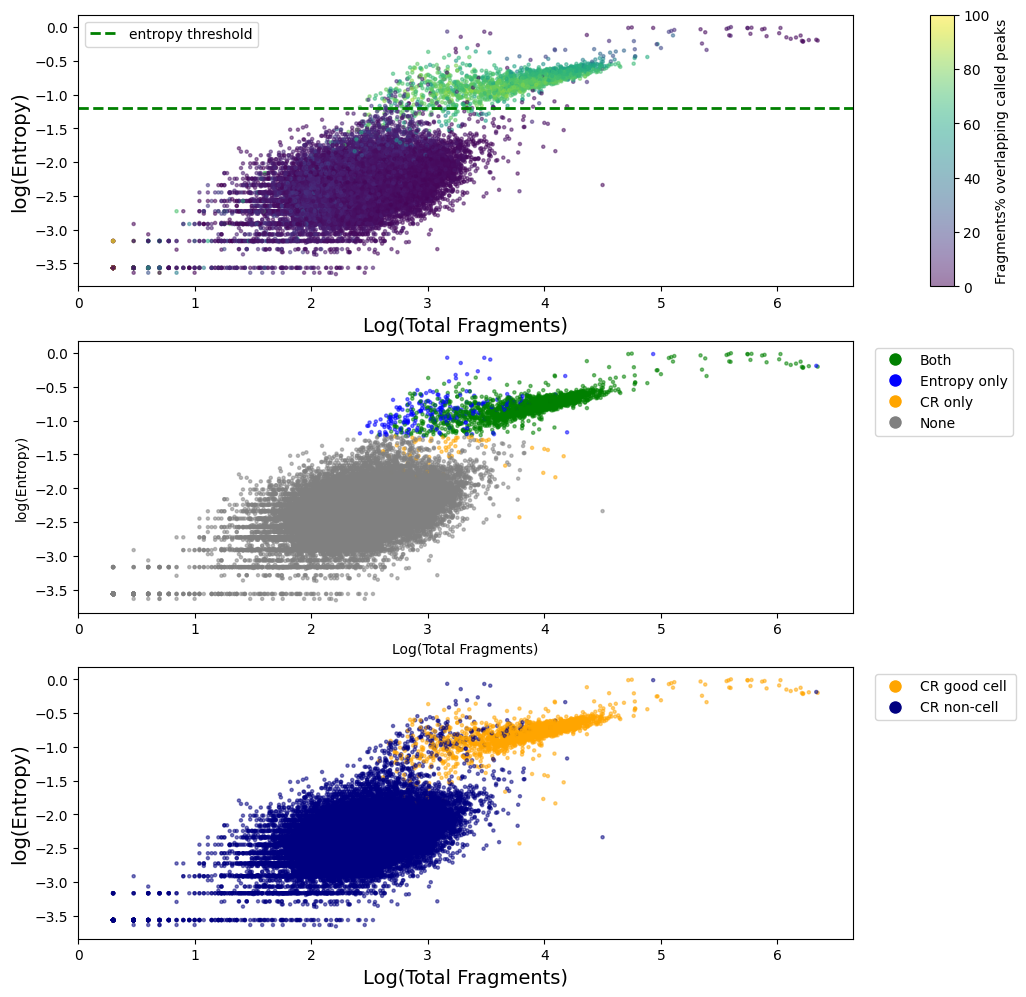

In [133]:
fig, ax = plt.subplots(3, 1, figsize=(10, 12) )
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}
ax[1].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']),  c= all_df['identified_by'].map(colors), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors.items()]
ax[1].legend(title='color', handles=handles, bbox_to_anchor=(0.8, 0.5), loc='upper left')
ax[1].set_xlabel('Log(Total Fragments)')
ax[1].set_ylabel('log(Entropy)')

ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[0].set_ylabel('log(Entropy)', fontsize=14)
ax[0].axhline(-1.1975644015016458, color='green', linestyle='--', label='entropy threshold', lw=2)
ax[0].text(-1.1975644015016458, .5,  '', color='green')
ax[0].legend() 


ax[1].legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1.02, 1), loc='upper left')

ax[2].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision), c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),
                alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[2].set_ylabel('log(Entropy)', fontsize=14)
ax[2].legend( handles=[Line2D([0], [0], marker='o', color='w', label='CR good cell ',
                          markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='CR non-cell',
                           markerfacecolor='navy', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')

cax_0 = ax[0].inset_axes([1.1, 0, 0.03, 1], transform=ax[0].transAxes)
#cax_2 = ax[2].inset_axes([1.1, 0, 0.03, 1], transform=ax[2].transAxes)

fig.colorbar(ax[0].collections[0], ax=ax[0], cax=cax_0, label='Fragments% overlapping called peaks')

rank_cutoff: 2125


/tmp/ipykernel_3645555/3057508297.py:46: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[2].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision), c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),


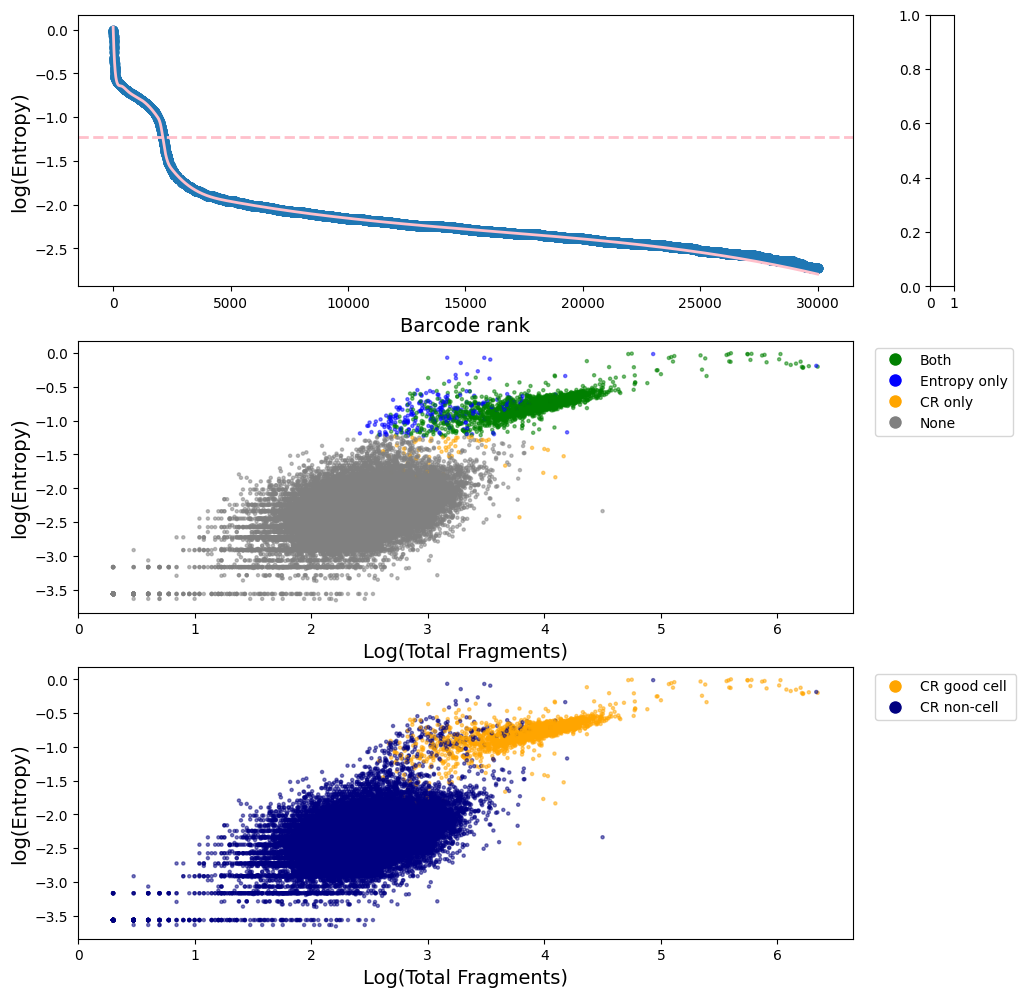

In [178]:
### For figures 

from autothreshold import fit_spline_and_find_cutoff

sorted_log10entropy_list = np.log10(all_df['Entropy_mixturedist'].dropna().sort_values(ascending=False).values)[:30000] # take top 30k for spline fitting
rank_list = np.arange( len(sorted_log10entropy_list) )

rank_cutoff, log10_entry_cutoff, cs = fit_spline_and_find_cutoff(rank_list, sorted_log10entropy_list, k=2, spline_s=1, spline_k=3)
print(f'rank_cutoff: {rank_cutoff}')

# 
all_df['Entropy_openregion_adj'] = np.log10(all_df['Entropy_open_region'] / all_df['Mp'] * (1- all_df['P0_open_region']))
Passed_Entropycutoff_df = all_df.loc[all_df['Entropy_mixturedist'] > 10 **(log10_entry_cutoff), :]




fig, ax = plt.subplots(3, 1, figsize=(10, 12) )
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}

ax[0].plot( rank_list, sorted_log10entropy_list, 'o')
ax[0].plot(rank_list, cs(rank_list), color='pink', lw=2, label='spline fit')
ax[0].set_xlabel('Barcode rank', fontsize=14)
ax[0].set_ylabel('log(Entropy)', fontsize=14)
ax[0].axhline(log10_entry_cutoff, color='pink', linestyle='--', label='entropy threshold', lw=2)


ax[1].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']),  c= all_df['identified_by'].map(colors), alpha=0.5, s=5, 
           )
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=v, label=k, markersize=8) for k, v in colors.items()]
ax[1].legend(title='color', handles=handles, bbox_to_anchor=(0.8, 0.5), loc='upper left')
ax[1].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[1].set_ylabel('log(Entropy)', fontsize=14)


ax[1].legend(handles=[Line2D([0], [0], marker='o', color='w', label='Both',
                          markerfacecolor='green', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy only',
                           markerfacecolor='blue', markersize=10), 
                 Line2D([0], [0], marker='o', color='w', label='CR only',
                           markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='None',
                           markerfacecolor='gray', markersize=10)],
             bbox_to_anchor=(1.02, 1), loc='upper left')

ax[2].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']+ precision), c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),
                alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)', fontsize=14)
ax[2].set_ylabel('log(Entropy)', fontsize=14)
ax[2].legend( handles=[Line2D([0], [0], marker='o', color='w', label='CR good cell ',
                          markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='CR non-cell',
                           markerfacecolor='navy', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')

cax_0 = ax[0].inset_axes([1.1, 0, 0.03, 1], transform=ax[0].transAxes)
#cax_2 = ax[2].inset_axes([1.1, 0, 0.03, 1], transform=ax[2].transAxes)

#fig.colorbar(ax[0].collections[0], ax=ax[0], cax=cax_0, label='Fragments% overlapping called peaks')




/tmp/ipykernel_3645555/1344487037.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[0, 1].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']), c=all_df['entropy_pass'].map({True: 'blue', False: 'grey'}),
/tmp/ipykernel_3645555/1344487037.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[2, 1].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']), c=all_df['final_cell_call'].map({True: 'red', False: 'grey'}),


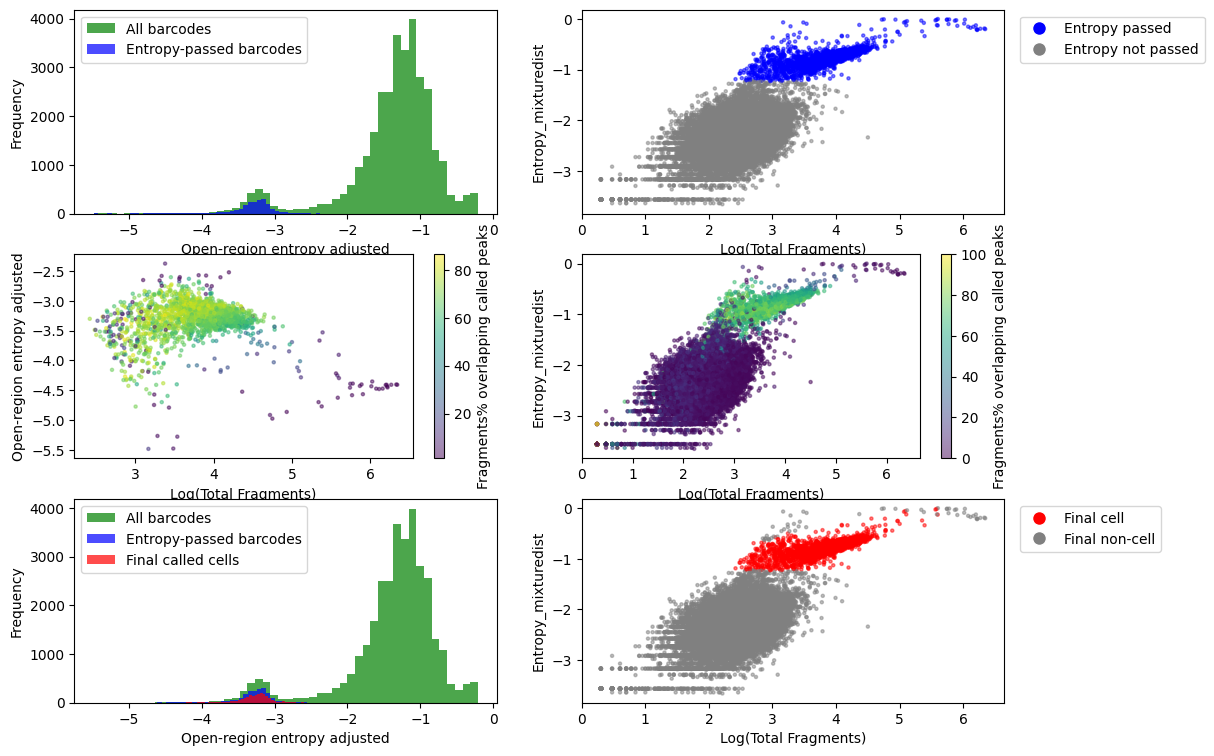

In [194]:
fig, ax = plt.subplots(3, 2, figsize=(12 ,9))
_ = ax[0, 0].hist(all_df['Entropy_openregion_adj'].dropna(), bins=50, color='green', alpha=0.7, label='All barcodes')
_ = ax[0, 0].hist(Passed_Entropycutoff_df['Entropy_openregion_adj'].dropna(), bins=50, color='blue', alpha=0.7, label='Entropy-passed barcodes')
ax[0, 0].set_xlabel('Open-region entropy adjusted')
ax[0, 0].set_ylabel('Frequency')
ax[0, 0].legend()

ax[1, 0].scatter( Passed_Entropycutoff_df['log(total_fragments)'], np.log10(Passed_Entropycutoff_df['Entropy_open_region']/ Passed_Entropycutoff_df['Mp'] * (1- Passed_Entropycutoff_df['P0_open_region']) ),
                c=Passed_Entropycutoff_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
ax[1, 0].set_xlabel('Log(Total Fragments)')
ax[1, 0].set_ylabel('Open-region entropy adjusted')
fig.colorbar(ax[1, 0].collections[0], ax=ax[1, 0], label='Fragments% overlapping called peaks')



log10Openregion_entropy = Passed_Entropycutoff_df['Entropy_openregion_adj'].values
_mean = log10Openregion_entropy.mean()
_std = log10Openregion_entropy.std()
z_scores = (log10Openregion_entropy - _mean) / _std 

## back to all_df
all_df['doublet_score'] = (all_df['Entropy_openregion_adj'] - _mean) / _std 
all_df['doublet_pass'] = np.abs(all_df['doublet_score']) <= 3


all_df['final_cell_call'] = (all_df['doublet_pass']) & (all_df['entropy_pass'])


ax[0, 1].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']), c=all_df['entropy_pass'].map({True: 'blue', False: 'grey'}),
                alpha=0.5, s=5, cmap='coolwarm')
ax[0, 1].set_xlabel('Log(Total Fragments)')
ax[0, 1].set_ylabel('Entropy_mixturedist')
ax[0, 1].legend( handles=[Line2D([0], [0], marker='o', color='w', label='Entropy passed',
                          markerfacecolor='blue', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Entropy not passed',
                           markerfacecolor='grey', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')


ax[1, 1].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']), c=all_df['frag_overlap_entropy_peaks%'],
                alpha=0.5, s=5, cmap='viridis')
ax[1, 1].set_xlabel('Log(Total Fragments)')
ax[1, 1].set_ylabel('Entropy_mixturedist')
fig.colorbar(ax[1, 1].collections[0], ax=ax[1, 1], label='Fragments% overlapping called peaks')


ax[2, 1].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_mixturedist']), c=all_df['final_cell_call'].map({True: 'red', False: 'grey'}),
                alpha=0.5, s=5, cmap='coolwarm')
ax[2, 1].set_xlabel('Log(Total Fragments)')
ax[2, 1].set_ylabel('Entropy_mixturedist')
ax[2, 1].legend( handles=[Line2D([0], [0], marker='o', color='w', label='Final cell',
                          markerfacecolor='red', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='Final non-cell',
                           markerfacecolor='grey', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')




_ = ax[2, 0].hist(all_df['Entropy_openregion_adj'].dropna(), bins=50, color='green', alpha=0.7, label='All barcodes')
_ = ax[2, 0].hist(Passed_Entropycutoff_df['Entropy_openregion_adj'].dropna(), bins=50, color='blue', alpha=0.7, label='Entropy-passed barcodes')
_ = ax[2, 0].hist(all_df.loc[all_df['final_cell_call'], 'Entropy_openregion_adj'].dropna(), bins=50, color='red', alpha=0.7, label='Final called cells')
ax[2, 0].set_xlabel('Open-region entropy adjusted')
ax[2, 0].set_ylabel('Frequency')
ax[2, 0].legend()

In [183]:
Passed_Entropycutoff_df['Entropy_openregion_adj'].values.mean(), Passed_Entropycutoff_df['Entropy_openregion_adj'].values.std()

(np.float64(-3.313160983336571), np.float64(0.31440450096898315))

In [ ]:
np.log10(all_df['Entropy_openregion_adj'].dropna()

/home/syyang/python_virtuenv/atac_tobias3.13/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


AAACAAGCAAACCTAG-1   NaN
AAACAAGCAAAGAAGC-1   NaN
AAACAAGCAAATCCCT-1   NaN
AAACAAGCAACAGGGA-1   NaN
AAACAAGCAAGGGCTT-1   NaN
                      ..
TTTGTGAGTTGAGTCT-1   NaN
TTTGTGAGTTGCAAGA-1   NaN
TTTGTGAGTTGTCATA-1   NaN
TTTGTGAGTTTCCTCA-1   NaN
TTTGTGAGTTTGACTA-1   NaN
Name: Entropy_openregion_adj, Length: 33287, dtype: float64

rank_cutoff: 2122


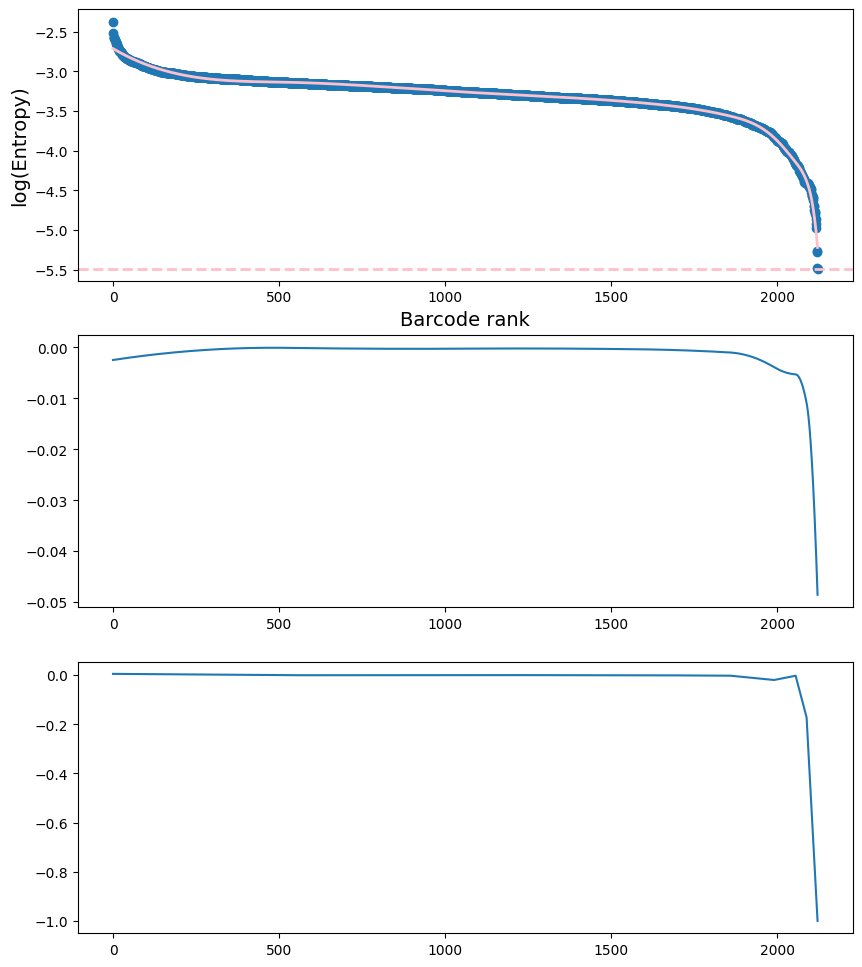

In [ ]:
log10Openregion_entropy = np.log10(Passed_Entropycutoff_df['Entropy_open_region'] / Passed_Entropycutoff_df['Mp'] * (1- Passed_Entropycutoff_df['P0_open_region']))
sorted_logOpenregion_entropy = log10Openregion_entropy.sort_values(ascending=False)

rank_list = np.arange( len(sorted_logOpenregion_entropy) )

rank_cutoff, log10_Openregionentry_cutoff, cs = fit_spline_and_find_cutoff(rank_list, sorted_logOpenregion_entropy, k=2, spline_s=1, spline_k=3)
print(f'rank_cutoff: {rank_cutoff}')



fig, ax = plt.subplots(3, 1, figsize=(10, 12) )
colors = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}

ax[0].plot( rank_list, sorted_logOpenregion_entropy, 'o')
ax[0].plot(rank_list, cs(rank_list), color='pink', lw=2, label='spline fit')
ax[0].set_xlabel('Barcode rank', fontsize=14)
ax[0].set_ylabel('log(Entropy)', fontsize=14)
ax[0].axhline(log10_Openregionentry_cutoff, color='pink', linestyle='--', label='entropy threshold', lw=2)


deriv = {}
for i in range(1, 3):
    deriv[i] = cs.derivative(i)(rank_list)

deriv[2] = deriv[2] / np.abs(deriv[2]).max()  # normalize second derivative for better visualization    


ax[1].plot(rank_list, deriv[1], label='first derivative')
ax[2].plot(rank_list, deriv[2], label='second derivative')

np.int64(1318)

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
color_map = {'both':'green', 'entropy_only':'blue', 'cr_only':'orange', 'none':'gray'}

all_df.boxplot(column=['frag_overlap_entropy_peaks%'], by='identified_by', ax=ax)
ax.set_ylim(0, 120)
ax.set_ylabel('Fragments% overlapping called peaks', fontsize=14)
ax.set_xlabel(' ')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(['Both', 'CR only', 'Entropy only', 'None'], fontsize=14)
ax.set_title('Barcode quality by different cell identification methods')
for i, method in enumerate(['both', 'cr_only', 'entropy_only', 'none']):
    ax.text(i + 0.5, 110, f'{(all_df["identified_by"]==method).sum()} BCs', fontsize=14, c=color_map[method])
plt.suptitle('')

# fig, ax = plt.subplots(figsize=(8,8))
# ax.violinplot(
#     [all_df.loc[all_df['identified_by'] == 'cr_only', 'frag_overlap_entropy_peaks%'], 
#      all_df.loc[all_df['identified_by'] == 'entropy_only', 'frag_overlap_entropy_peaks%'],
#      all_df.loc[all_df['identified_by'] == 'both', 'frag_overlap_entropy_peaks%']],
#     positions=[1, 2, 3],
#      showmedians=True
# )
# ax.set_xlabel('Identified good cells')
# ax.set_ylabel('Fragments% overlapping called peaks')
# ax.set_xticks([1, 2, 3])
# ax.set_xticklabels(['CR_only', 'Entropy_only', 'Both'])

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18 ,6))
ax = ax.flatten()
ax[0].violinplot([np.log10(all_df.loc[all_df['cr_bc'], 'Entropy_mixturedist'].dropna()+ precision) ,
                          np.log10(all_df.loc[~all_df['cr_bc'], 'Entropy_mixturedist'].dropna()+ precision)],
               showmeans=False)
ax[0].set_title('Entropy_mixturedist distribution on \n CR-called cells vs non-cells')


# 2-step entropy filtering

In [ ]:
remove_empty_index = all_df['Entropy_mixturedist'] > 10 ** ( -1.2295731856989456)
NonEmpty_df = all_df[remove_empty_index].copy()
NonEmpty_df.shape


In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(10,10))
_ = ax[0,0].hist(np.log10(NonEmpty_df['Entropy_open_region'] / NonEmpty_df['Mp'] ), bins=100)

ax[1, 0].scatter( np.log10(NonEmpty_df['Entropy_open_region'] / NonEmpty_df['Mp']  ), np.log10(NonEmpty_df['Entropy_mixturedist']), c=NonEmpty_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
ax[1, 0].set_xlabel('log(Entropy_open_region)')
ax[1, 0].set_ylabel('log(Entropy_mixturedist)')

normed_Entropy_open_region = NonEmpty_df['Entropy_open_region'] / NonEmpty_df['Mp'] 
normed_Entropy_open_region.sort_values(ascending=False, inplace=True)
ax[2, 0].scatter( np.arange(len(normed_Entropy_open_region)), np.log10(normed_Entropy_open_region), s=5, alpha=0.5)
ax[2, 0].set_xlabel('Barcode rank')
ax[2, 0].set_ylabel('log(Entropy_open_region)')


## 2nd column
ax[1,1].scatter( NonEmpty_df['log(total_fragments)'], np.log10(NonEmpty_df['Entropy_open_region'] / NonEmpty_df['Mp'] ), c=NonEmpty_df['frag_overlap_entropy_peaks%'], s=5, alpha=0.5)
ax[1, 1].set_xlabel('log(total_fragments)')
ax[1, 1].set_ylabel('log(Entropy_open_region)-adjusted by sample size')
fig.colorbar(ax[1,1].collections[0], ax=ax[1,1], label='frag_overlap_entropy_peaks%')

## Top 20k as pre-filter 

In [ ]:
top20k_df = all_df.sort_values(by='total_fragments_entropypeaks', ascending=False).head(20000)

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
_ = ax.hist(np.log10(top20k_df['Entropy_mixturedist']), bins=100)

In [ ]:
all_df['cr_bc'].value_counts()

In [ ]:
all_df[all_df['Entropy_mixturedist'] > 10**(-1.2295731856989456)].shape

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(np.arange(20000), np.log10(top20k_df['Entropy_mixturedist'].sort_values(ascending=False) + precision), s=10)
ax.set_ylabel('log(Entropy_mixturedist)')
ax.set_xlabel('Ranked Barcodes (by Entropy_mixturedist)')

In [ ]:


special_bc = 'GACAGGCTCGAGGAGG-1'  # bad-quality cell -- probably over-tagmented 

fig, ax = plt.subplots( figsize=(12,12))
ax.scatter( top20k_df['log(total_fragments)'], np.log10(top20k_df['Entropy_mixturedist']), c=top20k_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax.set_xlabel('Log(Total Fragments)')
ax.set_ylabel('log(Entropy_mixturedist)')
ax.scatter(top20k_df.loc[special_bc, 'log(total_fragments)'], np.log10(top20k_df.loc[special_bc, 'Entropy_mixturedist'] + precision),
              color='red', s=50, label='special_bc')
ax.legend()


fig.colorbar(ax.collections[0], ax=ax, label='frag_overlap_entropy_peaks%')


# Non-0 window 

In [ ]:
cell_df = all_df[ (all_df['entropy_mixdist_c'] > 10 ** (-1.2)) & (all_df['total_fragments_entropypeaks'] < 10000)].copy()

special_bc = list(tn5_insert_freq.keys())[0]
total_windows = tn5_insert_freq[special_bc].shape[1] 

cell_df['N_open_regions'] = total_windows * (1 - cell_df['P_closed_state'])

for bc in cell_df.index:
    cell_df.loc[bc, 'N_nnz'] = tn5_insert_freq[bc].nnz

In [ ]:
np.isnan(0.1)

In [ ]:
cell_df.head()

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(12,6))
ax[0].scatter( cell_df['total_fragments_entropypeaks'], cell_df['N_open_regions'], c=cell_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('total_fragments_entropypeaks')       
ax[0].set_ylabel('N_open_regions')
ax[0].set_ylim(0, 10000)
ax[0].set_xlim(1000, 20000)


ax[1].scatter( cell_df['total_fragments_entropypeaks'], cell_df['N_nnz'], c=cell_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('total_fragments_entropypeaks')       
ax[1].set_ylabel('N_nnz')
ax[1].set_ylim(0, 1000)
ax[1].set_xlim(0, 20000)

ax[2].scatter( cell_df['total_fragments_entropypeaks'], cell_df['mle_lambda'], c=cell_df['frag_overlap_entropy_peaks%'], 
              alpha=0.5, s=5, cmap='viridis')
ax[2].set_xlabel('total_fragments_entropypeaks')       
ax[2].set_ylabel('N_nnz')
ax[2].set_ylim(0, 2)
ax[2].set_xlim(0, 20000)

In [ ]:
cell_df['total_fragments_entropypeaks'].min()

## linear regression on read-depth v.s. non-zero winds N-nnz 

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(  cell_df['total_fragments_entropypeaks'].values.reshape(-1, 1), cell_df['N_nnz'].values.reshape(-1, 1),)

reg.coef_, reg.intercept_

x_s = np.array([0, 10000]).reshape(-1, 1)
y_s = reg.predict(x_s)
pts = np.concatenate([x_s, y_s], axis=1)

fig, ax = plt.subplots( figsize=(6,6))
ax.scatter( cell_df['total_fragments_entropypeaks'], cell_df['N_nnz'], c=cell_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax.set_xlabel('total_fragments_entropypeaks')       
ax.set_ylabel('N_nnz')
# ax.set_ylim(0, 1000)
# ax.set_xlim(0, 20000)
ax.axline(pts[0], pts[1], color='red', linestyle='--', label='Linear Regression')

reg.coef_, reg.intercept_


In [ ]:
(54  - reg.intercept_[0]) / reg.coef_[0][0]

In [ ]:
32 / 0.0807

In [ ]:
depth = 262
np.log10(depth),  depth * reg.coef_[0][0] + reg.intercept_[0]

# See Tn5 Insertions

## Set 1

In [ ]:
subset_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-.8)) & (all_df['kl_divergence'] < 3)]

good_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-1.)) & (all_df['kl_divergence'] > 3)]

crazy_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-0.5)) & (all_df['log(total_fragments)'] > 4)]

fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 66, 70# 82 , 82 seed is vip 

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[sample_bc[0], 'kl_divergence']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])     
        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[good_bc[0], 'kl_divergence']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth}, frag-overlap:{np.round(bc_frag_overlap, 3)} kl {kl_divergence_val}', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()} ',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[crz_bc[0], 'kl_divergence']
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

fig.suptitle('Observed tn5 insertion rates (randomly sampled barcodes)', fontsize=20)
fig.tight_layout()

In [ ]:
bc = 'AATCATGAGTATCGCC-1'

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
bc_seq_depth = int(all_df.loc[bc, 'total_fragments_entropypeaks'])
bc_logentropy_val = all_df.loc[bc, 'log(entropy)']
bc_frag_overlap = all_df.loc[bc, 'frag_overlap_entropy_peaks%']
entropy_mix = all_df.loc[bc, 'entropy_mixdist_c']
kl_divergence_val = all_df.loc[bc, 'kl_divergence']

val, freq = np.unique(tn5_insert_freq[bc].toarray(), return_counts=True)
p_non0 = freq[1:]/  np.sum(freq[1:])     
ax[0].plot(val, freq, marker='o', 
        label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
ax[ 0].tick_params(labelbottom=True)

ax[ 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)
ax[0].legend()
ax[1].legend()

all_df.loc['AATCATGAGTATCGCC-1']


In [ ]:
possible_overtag_bc_frag = pd.read_csv('/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000/_possible_overtag_bc_frag.tsv', sep='\t', header=None)
fig, ax = plt.subplots(1, 2, figsize=(12,6))

possible_good_bc_frag = pd.read_csv('/mnt/hdd_bob/syy/adipose/atac/res/VIB_10xmultiome_2_WS3000/_possible_goodbc_frag.tsv', sep='\t', header=None)

ax[0].hist(possible_overtag_bc_frag[2] - possible_overtag_bc_frag[1], log=False, bins=100, label='overtag?')

ax[1].hist(possible_good_bc_frag[2] - possible_good_bc_frag[1], log=False, bins=100, label='good bc?')

ax[0].legend()
ax[1].legend()

In [ ]:
subset_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-1.2)) & (all_df['kl_divergence'] < 3)]

good_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-1.2)) & (all_df['kl_divergence'] > 3)]

crazy_df = all_df[(all_df['entropy_mixdist_c'] > 10 ** (-0.5)) & (all_df['log(total_fragments)'] > 4)]

fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[sample_bc[0], 'kl_divergence']

        val, freq = break_down_freq(tn5_insert_freq[sample_bc[0]].toarray())
        freq[freq == None] =  -1 
        p_non0 = freq/  np.sum(freq)     

        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[good_bc[0], 'kl_divergence']

        val, freq = break_down_freq(tn5_insert_freq[good_bc[0]].toarray())
        freq[freq == None] =  -1 
        p_non0 = freq/  np.sum(freq) 
        ax[1, 0].plot(val, freq, marker='o',
                label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_mixdist_c']
        kl_divergence_val = all_df.loc[crz_bc[0], 'kl_divergence']
        
        val, freq = break_down_freq(tn5_insert_freq[crz_bc[0]].toarray())
        freq[freq == None] =  -1 
        p_non0 = freq/  np.sum(freq) 
        ax[2, 0].plot(val, freq, marker='o', label=f'seqdepth:{bc_seq_depth},  frag-overlap:{np.round(bc_frag_overlap, 3)}  kl {kl_divergence_val}', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[2:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()
        
fig.suptitle('  ------------------    ------         ----------------------------      break down 0-freq to closed and open regions', fontsize=20)
fig.tight_layout()

In [ ]:
all_df.loc['CTCAGCTAGCCAGTAG-1']

In [ ]:
np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)[1].sum()

In [ ]:
all_df.loc[((all_df['kl_divergence'] > 4) & (all_df['log(total_fragments)'] > 3))]

## Set 2

In [ ]:
bad_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] < 30) ]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] > 50) ]

crazy_df = all_df[(all_df['log(total_fragments)'] >  3) &  (all_df['frag_overlap_entropy_peaks%'] < 30) ]


fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = bad_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = np.unique(tn5_insert_freq[sample_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])     
        ax[0, 0].plot(val[1:], freq[1:], marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = np.unique(tn5_insert_freq[good_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[1, 0].plot(val[1:], freq[1:], marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = np.unique(tn5_insert_freq[crz_bc[0]].toarray(), return_counts=True)
        p_non0 = freq[1:]/  np.sum(freq[1:])
        ax[2, 0].plot(val[1:], freq[1   :], marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val[1:], p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

In [ ]:
bad_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] < 30) ]

good_df = all_df[(all_df['entropy_final'] > 10 ** (-1.6)) & (all_df['log(total_fragments)'] < 3) & (all_df['frag_overlap_entropy_peaks%'] > 50) ]

crazy_df = all_df[(all_df['log(total_fragments)'] >  3) &  (all_df['frag_overlap_entropy_peaks%'] < 30) ]


fig, ax = plt.subplots(3, 2, figsize=(18,12), sharex=True)

bc_list = subset_df.index.tolist()
good_list = good_df.index.tolist()
crazy_list = crazy_df.index.tolist()

record_plot_bcs = []

Imin, Imax = 75, 78

for i in range(Imin, Imax):
        np.random.seed(i)

        sample_bc = np.random.choice(bc_list, size=1, replace=False)

        record_plot_bcs.append([sample_bc[0], 'bc'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[sample_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[sample_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[sample_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[sample_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[sample_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq)     
        ax[0, 0].plot(val, freq, marker='o', 
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[0, 0].tick_params(labelbottom=True)

        ax[0, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)



        good_bc = np.random.choice(good_list, size=1, replace=False)
        record_plot_bcs.append([good_bc[0], 'good'])

        # for sampled good barcode
        bc_seq_depth = int(all_df.loc[good_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[good_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[good_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[good_bc[0], 'entropy_final']

        val, freq = break_down_freq(tn5_insert_freq[good_bc[0]].toarray())
        p_non0 = freq/  np.sum(freq) 
        ax[1, 0].plot(val, freq, marker='o',
                label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[1, 0].tick_params(labelbottom=True)

        ax[1, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
                alpha=0.7)

        crz_bc = np.random.choice(crazy_list, size=1, replace=False)
        record_plot_bcs.append([crz_bc[0], 'crazy'])
        # for sampled crazy barcode
        bc_seq_depth = int(all_df.loc[crz_bc[0], 'total_fragments_entropypeaks'])
        bc_logentropy_val = all_df.loc[crz_bc[0], 'log(entropy)']
        bc_frag_overlap = all_df.loc[crz_bc[0], 'frag_overlap_entropy_peaks%']
        entropy_mix = all_df.loc[crz_bc[0], 'entropy_final']
        val, freq = break_down_freq(tn5_insert_freq[crz_bc[0]].toarray())

        val = val[freq != None]
        freq = freq[freq != None]
        p_non0 = freq/  np.sum(freq) 
        ax[2, 0].plot(val, freq, marker='o', label=f'seqdepth:{bc_seq_depth}, log(entrp):{np.round(bc_logentropy_val, 3)} frag-overlap:{np.round(bc_frag_overlap, 3)} ', alpha=0.7)
        ax[2, 0].tick_params(labelbottom=True)
        ax[2, 1].plot(val, p_non0, marker='o', label = f'mix_entropy {np.log10(entropy_mix):.3f} non-0-freq {freq[1:].sum()}',
        alpha=0.7)




        ax[0, 1].tick_params(labelbottom=True)
        ax[0, 0].legend()
        ax[0, 1].legend()
        ax[1, 1].tick_params(labelbottom=True)
        ax[1, 0].legend()
        ax[1, 1].legend()
    
        ax[2, 1].tick_params(labelbottom=True)
        ax[2, 0].legend()
        ax[2, 1].legend()

# Plot entropy of mixture distribution

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(12,12))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[0].collections[0], ax=ax[0], label='frag_overlap_entropy_peaks%')

ax[1].scatter(all_df['log(entropy)'], np.log10(all_df['entropy_mixdist']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(entropy)')
ax[1].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[1].collections[0], ax=ax[1], label='frag_overlap_entropy_peaks%')


ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['entropy_mixdist']+ precision),  c=all_df['cr_bc'],
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(entropy_mixdist)')
fig.colorbar(ax[2].collections[0], ax=ax[2], label='cr_bc')

# To calculate Entropy without correcting on sample-size 

In [ ]:
# To calculate Entropy without correcting on sample-size 

all_df['Entropy_nocorrected'] = all_df['Entropy_mixturedist'] - ( 1- all_df['P_closed_state']) * all_df['Entropy_open_region'] * (  (1 - all_df['P0_open_region']) / all_df['Mp']   - 1 )

fig, ax = plt.subplots(3, 1, figsize=(10,10))
ax[0].scatter( all_df['log(total_fragments)'], np.log10(all_df['Entropy_nocorrected']+ precision), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[0].set_xlabel('Log(Total Fragments)')
ax[0].set_ylabel('log(Entropy_nocorrected)')

ax[1].scatter(np.log10(all_df['Entropy_mixturedist']+ precision), np.log10(all_df['Entropy_nocorrected']), c=all_df['frag_overlap_entropy_peaks%'], 
           alpha=0.5, s=5, cmap='viridis')
ax[1].set_xlabel('Log(Entropy_mixturedist)')
ax[1].set_ylabel('log(ssize_adj_entropy)')



ax[2].scatter(all_df['log(total_fragments)'], np.log10(all_df['Entropy_nocorrected']+ precision),  c=all_df['cr_bc'].map({True: 'orange', False: 'navy'}),
              alpha=0.5, s=5, cmap='coolwarm')
ax[2].set_xlabel('Log(Total Fragments)')
ax[2].set_ylabel('log(Entropy_nocorrected)')
ax[2].legend( handles=[Line2D([0], [0], marker='o', color='w', label='CR cell barcode',
                          markerfacecolor='orange', markersize=10),
                 Line2D([0], [0], marker='o', color='w', label='CR non-cell barcode',
                           markerfacecolor='navy', markersize=10)],
           bbox_to_anchor=(1.02, 1), loc='upper left')

# Align colorbar and legend
cbax_0 = ax[0].inset_axes([1.1, 0, 0.03, 1], transform=ax[0].transAxes)
fig.colorbar(ax[0].collections[0], ax=ax[0], cax=cbax_0, label='frag_overlap_entropy_peaks%')


cbax_1 = ax[1].inset_axes([1.1, 0, 0.03, 1], transform=ax[1].transAxes)
fig.colorbar(ax[1].collections[0], ax=ax[1], cax=cbax_1, label='frag_overlap_entropy_peaks%')


fig.subplots_adjust(wspace=0.3)